# MultiVelo
Preliminary experiment to test the functionality of the MultiVelo method on our dataset

In [1]:
import os
import scipy
import numpy as np
import pandas as pd
import scanpy as sc
import scvelo as scv
import multivelo as mv
import matplotlib.pyplot as plt
from pathlib import Path

In [2]:
scv.settings.verbosity = 3
scv.settings.presenter_view = True
scv.set_figure_params('scvelo')
pd.set_option('display.max_columns', 100)
pd.set_option('display.max_rows', 200)
np.set_printoptions(suppress=True)

In [3]:
python_data_dir = r"C:\Users\Nikla\Documents\MoBi_Master_FS.3\Internship AG Höfer\DynaVelo_testing\data"

# Load RNA data
total_counts_path = rf"{python_data_dir}\all_rna_counts_normalized.h5ad"
adata_rna = sc.read_h5ad(total_counts_path)

In [4]:
# Normalization is not carried out, as this data is already filtered and normalized. Inclusion, because MultiVelo documentation suggests to do so.
scv.pp.filter_and_normalize(adata_rna, min_shared_counts=10, n_top_genes=1000)
adata_rna.obs.rename(columns={"cell_type": "celltype"}, inplace=True)  # Rename column to match MultiVelo documentation

Filtered out 1 genes that are detected 10 counts (shared).
Extracted 1000 highly variable genes.


### First run

In [ ]:
# Load ATAC data (took 15min, 42s last time)
data_path = Path(python_data_dir) / "filtered_feature_bc_matrix"
adata_atac = sc.read_10x_mtx(data_path, var_names='gene_symbols', gex_only=False)
adata_atac = adata_atac[:,adata_atac.var['feature_types'] == "Peaks"]
#adata_atac.write_h5ad(fr"{python_data_dir}\all_atac_peaks.h5ad")

### Rerun

In [6]:
adata_atac = sc.read_h5ad(rf"{python_data_dir}\all_atac_peaks.h5ad")

In [7]:
adata_atac  # shape of 7073 x 160142

AnnData object with n_obs × n_vars = 7073 × 160142
    var: 'gene_ids', 'feature_types'

In [8]:
# First we need to select only the cells that are left after filtering the RNA data
rna_cells = adata_rna.obs_names
atac_cells_renamed = [cell.replace("-1", "") for cell in adata_atac.obs_names]
adata_atac.obs_names = atac_cells_renamed
atac_cells = adata_atac.obs_names

intersection_cells = rna_cells.intersection(atac_cells)

adata_rna_intersected = adata_rna[intersection_cells, :]  # Already in cells-by-gene
adata_atac_intersected = adata_atac[intersection_cells, :]  # Convert to cells-by-peak

In [9]:
adata_atac = mv.aggregate_peaks_10x(adata_atac_intersected,
                                    fr"{python_data_dir}\atac_peak_annotation.tsv",
                                    fr"{python_data_dir}\feature_linkage.bedpe")

  0%|          | 0/18552 [00:00<?, ?it/s]

In [ ]:
adata_atac.write_h5ad(fr"{python_data_dir}\all_atac_aggregated_peaks.h5ad")
adata_atac  # Shape of 5241 x 18552 

View of AnnData object with n_obs × n_vars = 5241 × 18552

In [10]:
shared_cells = pd.Index(np.intersect1d(adata_rna.obs_names, adata_atac.obs_names))
shared_genes = pd.Index(np.intersect1d(adata_rna.var_names, adata_atac.var_names))
len(shared_cells), len(shared_genes)

(5241, 957)

In [11]:
adata_rna = sc.read_h5ad(total_counts_path)
scv.pp.filter_and_normalize(adata_rna, min_shared_counts=10, n_top_genes=1000)
adata_rna.obs.rename(columns={"cell_type": "celltype"}, inplace=True)
adata_atac = sc.read_h5ad(fr"{python_data_dir}\all_atac_aggregated_peaks.h5ad")

# Ensure both modalities have the same cells and genes
adata_rna = adata_rna[shared_cells, shared_genes]
adata_atac = adata_atac[shared_cells, shared_genes]

Filtered out 1 genes that are detected 10 counts (shared).
Extracted 1000 highly variable genes.


computing neighbors
    finished (0:00:12) --> added 
    'distances' and 'connectivities', weighted adjacency matrices (adata.obsp)
computing moments based on connectivities
    finished (0:00:00) --> added 
    'Ms' and 'Mu', moments of un/spliced abundances (adata.layers)


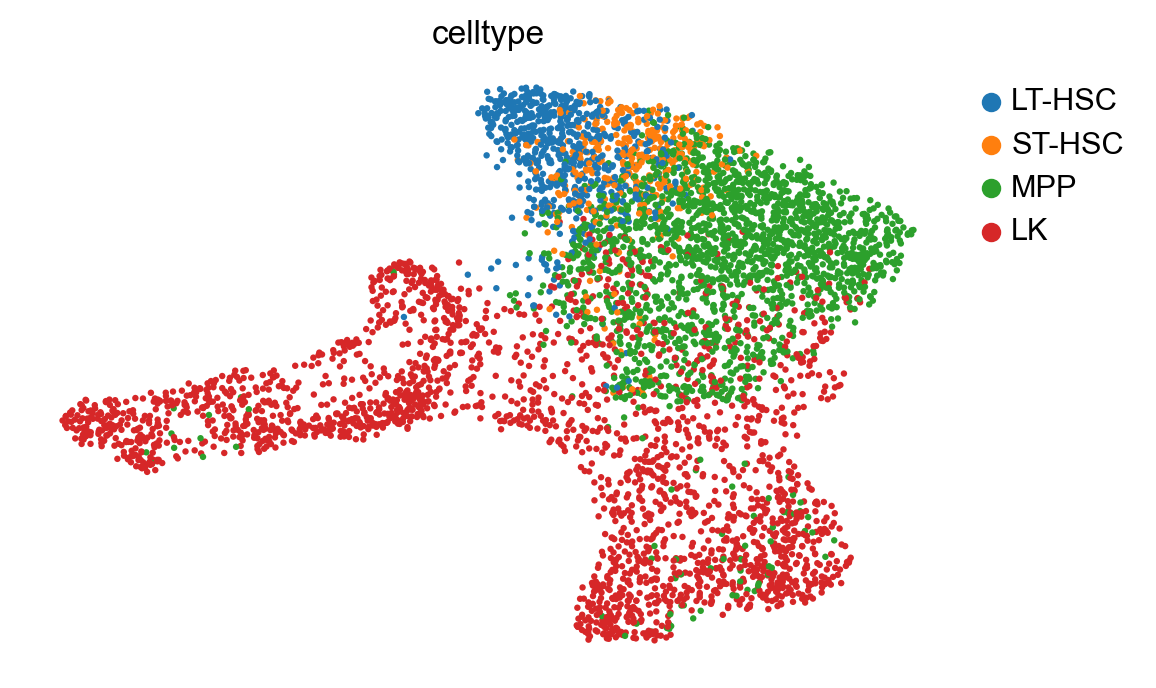

In [12]:
scv.pp.normalize_per_cell(adata_rna)
scv.pp.log1p(adata_rna)
scv.pp.moments(adata_rna, n_pcs=30, n_neighbors=50)

scv.tl.umap(adata_rna)
scv.pl.umap(adata_rna, color='celltype')

In [19]:
adata_rna.obs_names.to_frame().to_csv('filtered_cells.txt', header=False, index=False)

nn_idx = np.loadtxt(rf"{python_data_dir}/nn_idx.txt", delimiter=',')
nn_dist = np.loadtxt(rf"{python_data_dir}/nn_dist.txt", delimiter=',')
nn_cells = pd.Index(pd.read_csv(rf"{python_data_dir}/nn_cells.txt", header=None)[0])

nn_cells = nn_cells.str.replace('-1', '', regex=False)

np.all(nn_cells == adata_atac.obs_names)

True

In [20]:
mv.knn_smooth_chrom(adata_atac, nn_idx, nn_dist)
adata_atac

AnnData object with n_obs × n_vars = 5241 × 957
    layers: 'Mc'
    obsp: 'connectivities'

In [ ]:
adata_result = mv.recover_dynamics_chrom(adata_rna,
                                         adata_atac,
                                         max_iter=5,
                                         init_mode="invert",
                                         parallel=True,
                                         save_plot=False,
                                         rna_only=False,
                                         fit=True,
                                         n_anchors=500,
                                         extra_color_key='celltype'
                                        )

In [ ]:
adata_result.write("multivelo_result.h5ad")
adata_result = sc.read_h5ad("multivelo_result.h5ad")
mv.velocity_graph(adata_result)
mv.latent_time(adata_result)
mv.velocity_embedding_stream(adata_result, basis='umap', color='celltype')